In [1]:
!pip install ijson==3.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 4.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import logging
from glob import glob

# unless pre preprocessing changes, no need to run above

In [ ]:
imu_sensor_locations = ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg',
                    'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']

insole_sensor_locations = ['Arch', 'Hallux', 'Heel_L', 'Heel_R', 'Met1', 'Met3', 'Met5', 'Toes']

participant_num = [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25]

In [ ]:
import pandas as pd
import glob

# List of desired sensor locations
insole_sensor_locations = ['Arch', 'Hallux', 'Heel_L', 'Heel_R', 'Met1', 'Met3', 'Met5', 'Toes']

# Specify the directory where your ORIGINAL CSV files are stored
original_data_dir = "/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/processed_data"  # Replace with the correct path

# Create an empty list to store the DataFrames
insole_dfs = []

# Use glob to find files that match the pattern with insole sensor locations
for location in insole_sensor_locations:
    file_pattern = f"{original_data_dir}/*_{location}_*.csv"
    files = glob.glob(file_pattern)

    for file in files:
        try:
            # Load the CSV file
            df = pd.read_csv(file)

            # Debugging: Print file name and DataFrame shape
            print(f"Loaded: {file}, Shape: {df.shape}")

            # Append the DataFrame to the list
            insole_dfs.append(df)
        except Exception as e:
            # Handle any errors during file reading
            print(f"Error loading {file}: {e}")

# Combine all the DataFrames into one (optional)
if insole_dfs:
    combined_df = pd.concat(insole_dfs, ignore_index=True)
    print(f"Combined DataFrame Shape: {combined_df.shape}")
else:
    print("No matching files were loaded.")


In [ ]:
insole_df = combined_df.copy()

In [ ]:
insole_df = insole_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'])

In [ ]:
insole_df['walk_mode'].value_counts()

In [ ]:
# show all the rows in the df
pd.set_option('display.max_rows', None)

In [ ]:
# Function to pair heel strikes with the next toe-off event
def pair_heel_strikes_toe_offs(heel_strikes, toe_offs):
    pairs = []
    toe_idx = 0
    # Loop over each heel strike
    for heel in heel_strikes:
        # Find the next toe-off that occurs after the heel strike
        while toe_idx < len(toe_offs) and toe_offs[toe_idx] < heel:
            toe_idx += 1
        if toe_idx < len(toe_offs):
            # Pair found
            pairs.append((heel, toe_offs[toe_idx]))
            toe_idx += 1  # Move to the next toe-off for the next pair
    return pairs


In [ ]:
# Initialize step count columns
insole_df['right_step_count'] = np.nan
insole_df['left_step_count'] = np.nan

for p, participant_df in insole_df.groupby('participant_id'):
    for t in participant_df['task'].unique():
        # print(f"Processing participant {p}, task {t}...")
        # print("-------------------------")

        # Filter once per participant-task
        current_df = participant_df[participant_df['task'] == t].copy()

        # Define heel strikes and toe-offs for the right foot
        right_foot_heel_strikes = current_df[
            (current_df['insoles_RightFoot_is_step'] == True) &
            (current_df['insoles_RightFoot_is_lifted'] == False)]
        right_foot_toe_off = current_df[
            (current_df['insoles_RightFoot_is_step'] == False) &
            (current_df['insoles_RightFoot_is_lifted'] == True)]

        # Define heel strikes and toe-offs for the left foot
        left_foot_heel_strikes = current_df[
            (current_df['insoles_LeftFoot_is_step'] == True) &
            (current_df['insoles_LeftFoot_is_lifted'] == False)]
        left_foot_toe_off = current_df[
            (current_df['insoles_LeftFoot_is_step'] == False) &
            (current_df['insoles_LeftFoot_is_lifted'] == True)]

        # Convert heel strikes and toe-offs to lists
        heel_strike_R = list(right_foot_heel_strikes['time'])
        toe_off_R = list(right_foot_toe_off['time'])

        heel_strike_L = list(left_foot_heel_strikes['time'])
        toe_off_L = list(left_foot_toe_off['time'])


        right_foot_steps = pair_heel_strikes_toe_offs(heel_strike_R, toe_off_R)
        left_foot_steps = pair_heel_strikes_toe_offs(heel_strike_L, toe_off_L)

        # Vectorized step count assignment
        for i, (start, end) in enumerate(right_foot_steps):
            mask = (current_df['time'] >= start) & (current_df['time'] <= end)
            current_df.loc[mask, 'right_step_count'] = i + 1

        for i, (start, end) in enumerate(left_foot_steps):
            mask = (current_df['time'] >= start) & (current_df['time'] <= end)
            current_df.loc[mask, 'left_step_count'] = i + 1

        # Update the original DataFrame (if necessary)
        insole_df.loc[current_df.index, ['right_step_count', 'left_step_count']] = current_df[['right_step_count', 'left_step_count']]

        print(f"Processed participant {p}, task {t}")



In [ ]:
insole_df['right_gait_cycle'] = insole_df['right_step_count'].fillna(method='ffill')
insole_df['left_gait_cycle'] = insole_df['left_step_count'].fillna(method='ffill')


In [ ]:
insole_df['participant_id'].unique()

In [ ]:
insole_df['left_gait_cycle'] = insole_df['left_gait_cycle'].astype(int) / 8
insole_df['right_gait_cycle'] = insole_df['right_gait_cycle'].astype(int) / 8

In [ ]:
insole_df['gait_cycle_id'] = insole_df['participant_id'].astype(str) + '_' + \
                         insole_df['left_gait_cycle'].astype(str) + '_' + \
                         insole_df['task'].astype(str)

In [ ]:
# Create a copy of the DataFrame to modify
final_combined_df = insole_df.copy()

In [ ]:
# Rename 'pavement_up' to 'stairs_up' and 'pavement_down' to 'stairs_down'
final_combined_df['walk_mode'] = final_combined_df['walk_mode'].replace({'pavement_up': 'stairs_up', 'pavement_down': 'stairs_down'})

In [ ]:
final_combined_df['walk_mode'].value_counts()

In [ ]:
final_combined_df.sort_values(by=['participant_id', 'gait_cycle_id', 'time', 'sensor_location'], inplace=True)

In [ ]:
final_combined_df['participant_id'].unique()

In [ ]:
import random

number_list = list(final_combined_df['participant_id'].unique())
random.seed(67)
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 3)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 3)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

In [ ]:
# Function to calculate cycle lengths
def calculate_cycle_lengths(df, sensor_location='Arch'):
    # Filter the data by sensor location
    df_sensor = df[df['sensor_location'] == sensor_location]

    # Calculate cycle lengths (number of entries per gait cycle)
    cycle_lengths = df_sensor.groupby('gait_cycle_id').size()

    return cycle_lengths

def calculate_bounds(cycle_lengths, margin=10, min_length=41, max_length=85):
    # Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
    q1 = np.percentile(cycle_lengths, 25)
    q3 = np.percentile(cycle_lengths, 75)
    iqr = q3 - q1

    # Define the bounds, ensuring they're within the defined min and max lengths
    lower_bound = max(q1 - 1.5 * iqr, min_length) - margin  # Ensure lower bound is not below min_length
    upper_bound = min(q3 + 1.5 * iqr, max_length) + margin  # Ensure upper bound is not above max_length

    return lower_bound, upper_bound

# Function to filter out cycle lengths outside the bounds
def filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound):
    # Filter out cycle lengths that are outside the calculated bounds
    return cycle_lengths[(cycle_lengths >= lower_bound) & (cycle_lengths <= upper_bound)]


In [ ]:
def get_valid_gait_cycle_ids(df, lower_bound, upper_bound, sensor_location='Arch'):
    # Calculate cycle lengths
    cycle_lengths = calculate_cycle_lengths(df, sensor_location=sensor_location)

    # Filter cycle lengths
    filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

    # Return valid gait cycle IDs
    return filtered_cycle_lengths.index

# Step 2: Filter the original DataFrame based on valid gait cycle IDs
def filter_original_dataframe(df, valid_gait_cycle_ids):
    # Keep only rows with valid gait_cycle_id values
    return df[df['gait_cycle_id'].isin(valid_gait_cycle_ids)]


In [ ]:
# Apply the cycle length calculation and filtering to the full dataset
cycle_lengths = calculate_cycle_lengths(final_combined_df)

# Calculate bounds (with margin for flexibility)
lower_bound, upper_bound = calculate_bounds(cycle_lengths)

# Filter the cycle lengths based on the calculated bounds
filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

# Get valid gait cycle IDs
valid_gait_cycle_ids = get_valid_gait_cycle_ids(final_combined_df, lower_bound, upper_bound)

# Filter the original DataFrame
filtered_final_combined_df = filter_original_dataframe(final_combined_df, valid_gait_cycle_ids)



# Now group by 'walk_mode' to examine cycle lengths by surface type
filtered_cycle_lengths_by_surface = {}
for surface in final_combined_df['walk_mode'].unique():
    # Filter data by surface and calculate cycle lengths
    surface_df = final_combined_df[final_combined_df['walk_mode'] == surface]
    surface_cycle_lengths = calculate_cycle_lengths(surface_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_surface_cycle_lengths = filter_cycle_lengths(surface_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_surface[surface] = filtered_surface_cycle_lengths


# Now group by 'participant' to examine cycle lengths by surface type
filtered_cycle_lengths_by_participant = {}
for participant in final_combined_df['participant_id'].unique():
    # Filter data by surface and calculate cycle lengths
    participant_df = final_combined_df[final_combined_df['participant_id'] == participant]
    participant_cycle_lengths = calculate_cycle_lengths(participant_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_participant_cycle_lengths = filter_cycle_lengths(participant_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_participant[participant] = filtered_participant_cycle_lengths

# Optional: Print out the results for each surface
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Filtered Cycle Lengths: {len(lengths)}")


In [ ]:
def biomech_metrics(gc_len):
    gait_cycle_duration = gc_len/ 60
    gait_cycles_per_min = 60/gait_cycle_duration
    steps_per_min = 2 * gait_cycles_per_min
    print(f"Gait cycle duration: {gait_cycle_duration} seconds")
    print(f"Gait cycles per minute: {gait_cycles_per_min}")
    print(f"Steps per minute: {steps_per_min}")

    return gait_cycle_duration, gait_cycles_per_min, steps_per_min

In [ ]:
lower_gc_duration, lower_gc_per_min, lower_step_per_min = biomech_metrics(lower_bound)

In [ ]:
upper_gc_duration, upper_gc_per_min, upper_step_per_min = biomech_metrics(upper_bound)

In [ ]:
# Print summary of filtered cycle lengths for each surface type
for surface, lengths in cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_surface.keys()
data = filtered_cycle_lengths_by_surface.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Surface')
plt.show()

In [ ]:
# Print summary of filtered cycle lengths for each surface type
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_surface.keys()
data = filtered_cycle_lengths_by_surface.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Surface')
plt.show()

Participant: 1, Min Length: 41, Max Length: 80, Count: 1717
Participant: 2, Min Length: 41, Max Length: 79, Count: 1564
Participant: 3, Min Length: 41, Max Length: 85, Count: 1469
Participant: 4, Min Length: 41, Max Length: 82, Count: 1579
Participant: 5, Min Length: 42, Max Length: 85, Count: 1448
Participant: 7, Min Length: 41, Max Length: 83, Count: 1632
Participant: 8, Min Length: 41, Max Length: 85, Count: 1704
Participant: 10, Min Length: 41, Max Length: 84, Count: 1596
Participant: 12, Min Length: 42, Max Length: 84, Count: 1772
Participant: 13, Min Length: 41, Max Length: 80, Count: 1546
Participant: 14, Min Length: 41, Max Length: 85, Count: 1463
Participant: 15, Min Length: 42, Max Length: 80, Count: 1607
Participant: 16, Min Length: 44, Max Length: 85, Count: 1619
Participant: 17, Min Length: 41, Max Length: 85, Count: 1350
Participant: 18, Min Length: 41, Max Length: 82, Count: 1668
Participant: 19, Min Length: 41, Max Length: 76, Count: 1422
Participant: 22, Min Length: 41

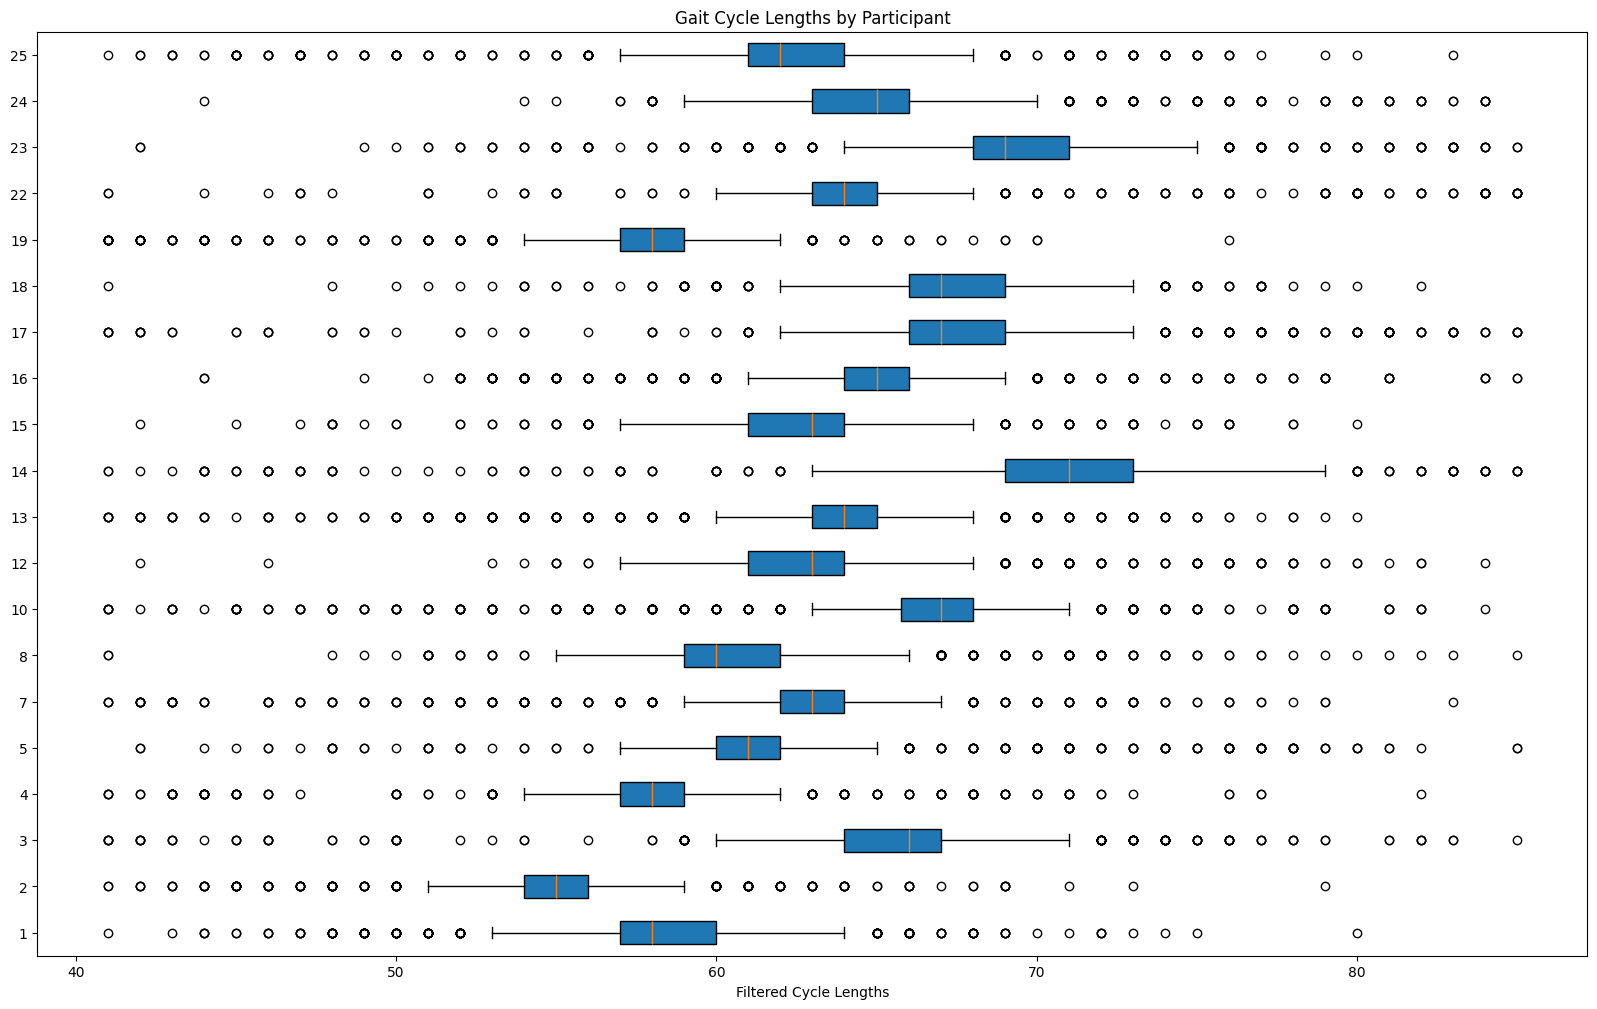

Participant: 1, Min Length: 41, Max Length: 80, Count: 1717
Participant: 2, Min Length: 41, Max Length: 79, Count: 1564
Participant: 3, Min Length: 41, Max Length: 85, Count: 1469
Participant: 4, Min Length: 41, Max Length: 82, Count: 1579
Participant: 5, Min Length: 42, Max Length: 85, Count: 1448
Participant: 7, Min Length: 41, Max Length: 83, Count: 1632
Participant: 8, Min Length: 41, Max Length: 85, Count: 1704
Participant: 10, Min Length: 41, Max Length: 84, Count: 1596
Participant: 12, Min Length: 42, Max Length: 84, Count: 1772
Participant: 13, Min Length: 41, Max Length: 80, Count: 1546
Participant: 14, Min Length: 41, Max Length: 85, Count: 1463
Participant: 15, Min Length: 42, Max Length: 80, Count: 1607
Participant: 16, Min Length: 44, Max Length: 85, Count: 1619
Participant: 17, Min Length: 41, Max Length: 85, Count: 1350
Participant: 18, Min Length: 41, Max Length: 82, Count: 1668
Participant: 19, Min Length: 41, Max Length: 76, Count: 1422
Participant: 22, Min Length: 41

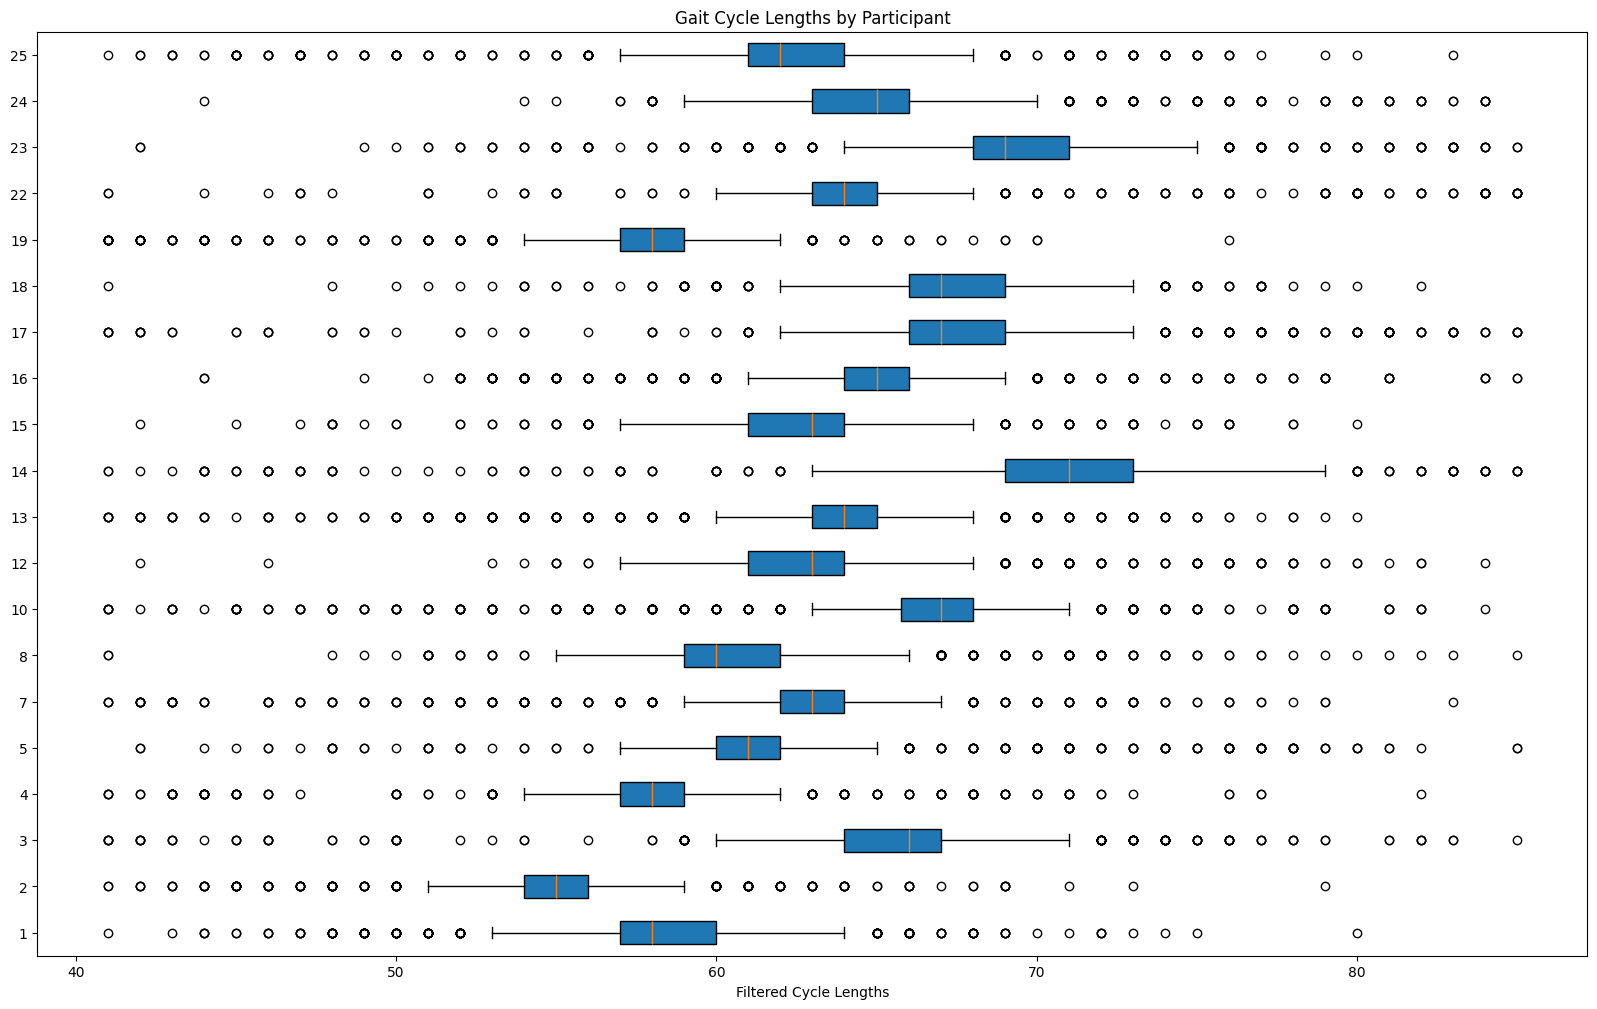

In [ ]:
# Print summary of filtered cycle lengths for each surface type
for participant, lengths in filtered_cycle_lengths_by_participant.items():
    print(f"Participant: {participant}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_participant.keys()
data = filtered_cycle_lengths_by_participant.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Participant')
plt.show()

In [ ]:
filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(
    filtered_final_combined_df['gait_cycle_id']
).values

<ipython-input-30-a251e6ce2436>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(


In [ ]:
all_gait_cycles = filtered_final_combined_df.copy()

In [ ]:
all_gait_cycles.sort_values(by=['participant_id', "left_gait_cycle", 'task'], inplace=True)

In [ ]:
all_gait_cycles.columns

Index(['time', 'participant_id', 'task', 'walk_mode',
       'insoles_RightFoot_is_step', 'insoles_RightFoot_is_lifted',
       'insoles_LeftFoot_is_step', 'insoles_LeftFoot_is_lifted',
       'sensor_location', 'Left_norm', 'Left_raw', 'Right_norm', 'Right_raw',
       'right_step_count', 'left_step_count', 'right_gait_cycle',
       'left_gait_cycle', 'gait_cycle_id', 'cycle_length'],
      dtype='object')

In [ ]:
all_gait_cycles['left_gait_cycle'].unique()

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 15

In [ ]:
def interpolate_to_fixed_length(group, target_length=80):
    interpolated_group = []

    # Iterate over each sensor location within the group
    for sensor_location, data in group.groupby('sensor_location'):
        # Select only numeric columns for interpolation
        numeric_data = data[['time', 'Right_raw', 'Left_raw', 'Left_norm', 'Right_norm']]
        numeric_data = numeric_data.reset_index(drop=True)
        original_length = len(numeric_data)

        if original_length < 2:
            # Skip groups with insufficient data for interpolation
            print(f"Skipping sensor_location '{sensor_location}' with insufficient data.")
            continue

        # Create new evenly spaced indices
        new_indices = np.linspace(0, original_length - 1, target_length)

        # Interpolate the numeric data to the new indices
        interpolated_data = pd.DataFrame(
            {col: np.interp(new_indices, np.arange(original_length), numeric_data[col])
             for col in numeric_data.columns},
            index=new_indices
        )

        # Add back the sensor location information
        interpolated_data['sensor_location'] = sensor_location
        interpolated_data['gait_cycle_id'] = group['gait_cycle_id'].iloc[0]
        interpolated_data['walk_mode'] = group['walk_mode'].iloc[0]

        # Append to the results list
        interpolated_group.append(interpolated_data)

    # Combine all sensor locations back into a single DataFrame
    return pd.concat(interpolated_group, axis=0) if interpolated_group else pd.DataFrame()


In [ ]:
# Apply the interpolation function
df_interpolated = (
    all_gait_cycles.groupby('gait_cycle_id')
    .apply(interpolate_to_fixed_length)
    .reset_index(drop=True)
)


<ipython-input-42-10383d9c33e5>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_to_fixed_length)


In [ ]:
len(df_interpolated)

20155520

In [ ]:
# def ensure_sensor_location_length_vectorized(df):

#     def interpolate_group(group):
#         new_index = pd.RangeIndex(0, 80)
#         return group.set_index(pd.RangeIndex(0, len(group))).reindex(new_index).interpolate(method='cubic')

#     # Create a MultiIndex with 'gait_cycle_id' and 'sensor_location'
#     df = df.set_index(['gait_cycle_id', 'sensor_location'])

#     # Apply the interpolation function to each group
#     df = df.groupby(['gait_cycle_id', 'sensor_location']).apply(interpolate_group).reset_index()

#     return df

# # Apply the vectorized function
# adjusted_df = ensure_sensor_location_length_vectorized(filtered_final_combined_df)

In [ ]:
df_interpolated.groupby('gait_cycle_id').count()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# interpolated_final_df['gait_cycle_id'].value_counts()

In [ ]:
df_interpolated.to_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/insole_sensor_df.csv', index=False)